In [30]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

X_train_scaled = joblib.load("../artifacts/X_train_scaled.pkl")
X_test_scaled = joblib.load("../artifacts/X_test_scaled.pkl")
y_train = joblib.load("../artifacts/y_train.pkl")
y_test = joblib.load("../artifacts/y_test.pkl")
feature_names = joblib.load("../artifacts/feature_names.pkl")

### Resultados Modelo

In [31]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

modelo.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [32]:
coefs = pd.DataFrame({
    'feature': feature_names,
    'beta': modelo.coef_[0]
}).sort_values(
    'beta',
    key=abs,
    ascending=False
).head(12)

coefs

,feature,beta
8,JobLevel,0.938366
41,JobRole_Sales Executive,0.851685
36,JobRole_Laboratory Technician,0.838159
45,OverTime_Yes,0.803702
42,JobRole_Sales Representative,0.738522
25,BusinessTravel_Travel_Frequently,0.654447
10,MonthlyIncome,-0.626653
29,EducationField_Life Sciences,-0.588351
23,YearsSinceLastPromotion,0.580135
18,TotalWorkingYears,-0.572599


Interpretación: No se pueden interpretar los Betas dado que las variables se encuentran estandarizadas sin embargo por a mayor beta positivo, mayor Attrition de la empresa, coincidentemente identificando como primeros roles a: Ejecutivo de ventas, tecnico de laboratorio y representante de ventas. Como carga laboral se podría identificar las horas extras como una variable fuerte para predecir la probabilidad de abandonar la empresa.

### Evaluación del Modelo

La evaluación de un modelo logístico, al igual que la evaluación de cualquier modelo de clasificación en el aprendizaje automático, implica medir su rendimiento en la tarea de clasificación de datos. En este caso, utilizaremos las siguientes:

- Matriz de Confusión
- Accuracy

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = modelo.predict(X_test_scaled)
y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision : {precision_score(y_test, y_pred):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
print(f"F1        : {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_proba):.3f}")

print("\n", classification_report(
    y_test,
    y_pred,
    target_names=["No Attrition", "Attrition"]
))

Accuracy  : 0.763
Precision : 0.376
Recall    : 0.718
F1        : 0.493
ROC AUC   : 0.824

               precision    recall  f1-score   support

No Attrition       0.93      0.77      0.85       408
   Attrition       0.38      0.72      0.49        78

    accuracy                           0.76       486
   macro avg       0.66      0.75      0.67       486
weighted avg       0.85      0.76      0.79       486



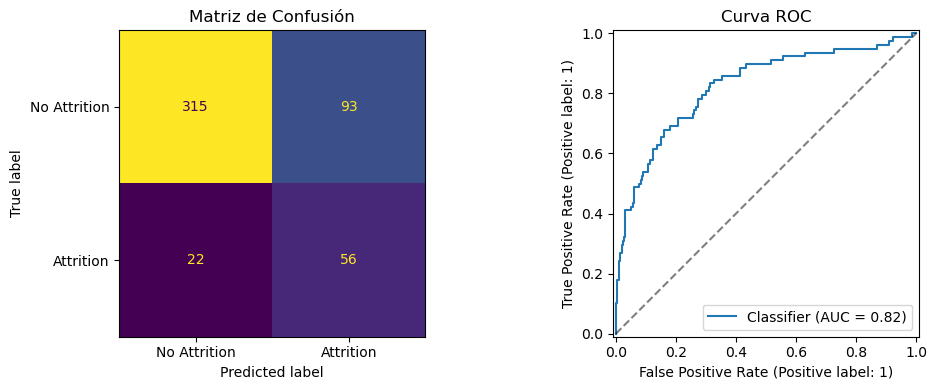

In [34]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Matriz de confusión
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["No Attrition", "Attrition"]
).plot(ax=axes[0], colorbar=False)

axes[0].set_title("Matriz de Confusión")

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    ax=axes[1]
)

axes[1].plot(
    [0, 1],
    [0, 1],
    "k--",
    alpha=0.5
)

axes[1].set_title("Curva ROC")

plt.tight_layout()
plt.show()

###### Interpretacion: El modelo logró una capacidad discriminatoria adecuada (ROC AUC = 0.824), identificando correctamente el 71.8% de los colaboradores que efectivamente abandonaron la organización (Recall). Sin embargo, la precisión fue moderada (37.6%), indicando que una proporción importante de las alertas de abandono correspondieron a falsos positivos. Dado el objetivo de detectar tempranamente posibles renuncias, se priorizó el Recall mediante el uso de ponderación de clases (class_weight='balanced'), aceptando una mayor tasa de falsas alarmas a cambio de reducir los casos de abandono no detectados.

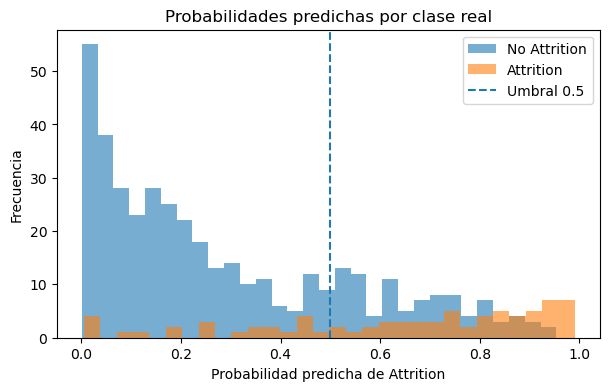

In [35]:
# --- Distribución de probabilidades por clase real ---

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

for label, name in [(0, "No Attrition"), (1, "Attrition")]:
    ax.hist(
        y_proba[y_test == label],
        bins=30,
        alpha=0.6,
        label=name
    )

ax.axvline(
    0.5,
    linestyle="--",
    label="Umbral 0.5"
)

ax.set_xlabel("Probabilidad predicha de Attrition")
ax.set_ylabel("Frecuencia")
ax.set_title("Probabilidades predichas por clase real")
ax.legend()

plt.show()

In [36]:
from sklearn.metrics import precision_recall_curve

In [37]:
coefs

,feature,beta
8,JobLevel,0.938366
41,JobRole_Sales Executive,0.851685
36,JobRole_Laboratory Technician,0.838159
45,OverTime_Yes,0.803702
42,JobRole_Sales Representative,0.738522
25,BusinessTravel_Travel_Frequently,0.654447
10,MonthlyIncome,-0.626653
29,EducationField_Life Sciences,-0.588351
23,YearsSinceLastPromotion,0.580135
18,TotalWorkingYears,-0.572599


In [38]:
import numpy as np

coefs["odds_ratio"] = np.exp(coefs["beta"])

coefs

,feature,beta,odds_ratio
8,JobLevel,0.938366,2.555801
41,JobRole_Sales Executive,0.851685,2.343592
36,JobRole_Laboratory Technician,0.838159,2.312106
45,OverTime_Yes,0.803702,2.233796
42,JobRole_Sales Representative,0.738522,2.092840
25,BusinessTravel_Travel_Frequently,0.654447,1.924079
10,MonthlyIncome,-0.626653,0.534378
29,EducationField_Life Sciences,-0.588351,0.555242
23,YearsSinceLastPromotion,0.580135,1.786279
18,TotalWorkingYears,-0.572599,0.564058
